✅ Анимация с ядром, частично выходящим за границы, сохранена.


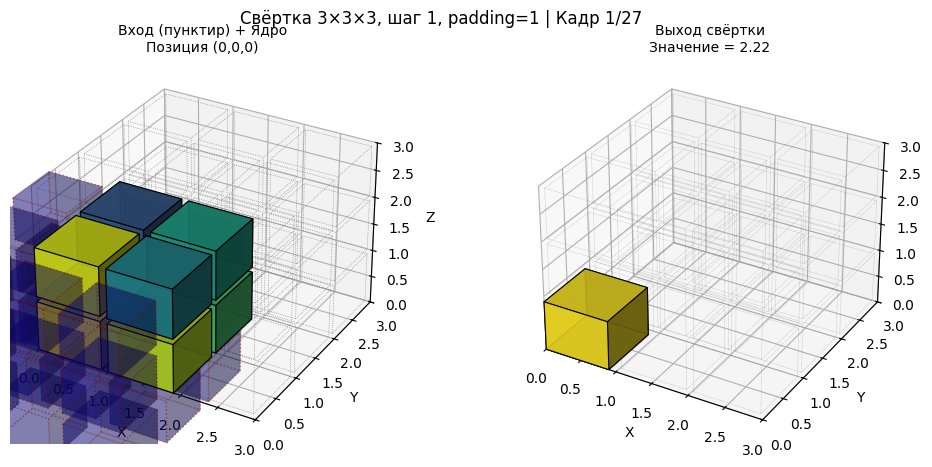

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

torch.manual_seed(42)
input_3d = torch.randn(1, 1, 3, 3, 3)
input_np = input_3d.squeeze().detach().numpy()

conv = nn.Conv3d(1, 1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv.weight.fill_(1.0)
weights_np = conv.weight.squeeze().detach().numpy()

output_np = conv(input_3d).squeeze().detach().numpy()

frames = []
for d_out in range(3):0
    for h_out in range(3):
        for w_out in range(3):
            frames.append({'pos': (d_out, h_out, w_out), 'val': output_np[d_out, h_out, w_out]})

vmin, vmax = input_np.min(), input_np.max()
wmin, wmax = weights_np.min(), weights_np.max()

fig = plt.figure(figsize=(12, 5))
ax_in = fig.add_subplot(121, projection='3d')
ax_out = fig.add_subplot(122, projection='3d')

def draw_cube_edges(ax, x, y, z, size=0.9, color='gray', linestyle=':', linewidth=0.5):
    """Рисует рёбра куба с центром в (x,y,z) как линии."""
    x0, y0, z0 = x - size/2, y - size/2, z - size/2
    x1, y1, z1 = x + size/2, y + size/2, z + size/2
    edges = [
        [(x0, y0, z0), (x1, y0, z0)], [(x0, y0, z0), (x0, y1, z0)], [(x0, y0, z0), (x0, y0, z1)],
        [(x1, y1, z1), (x0, y1, z1)], [(x1, y1, z1), (x1, y0, z1)], [(x1, y1, z1), (x1, y1, z0)],
        [(x1, y0, z0), (x1, y1, z0)], [(x1, y0, z0), (x1, y0, z1)],
        [(x0, y1, z0), (x1, y1, z0)], [(x0, y1, z0), (x0, y1, z1)],
        [(x0, y0, z1), (x1, y0, z1)], [(x0, y0, z1), (x0, y1, z1)],
    ]
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                color=color, linestyle=linestyle, linewidth=linewidth)

def update_conv(frame_idx):
    info = frames[frame_idx]
    d, h, w = info['pos']
    val = info['val']

    # --- ВХОД (прозрачный фон + пунктирные контуры всех вокселей) ---
    ax_in.clear()
    
    # Рисуем пунктирные каркасы всех входных вокселей
    for dz in range(3):
        for dy in range(3):
            for dx in range(3):
                draw_cube_edges(ax_in, dx+0.5, dy+0.5, dz+0.5, size=0.9,
                                color='gray', linestyle=':', linewidth=0.5)

    # Рисуем только воксели под ядром (цветные)
    for dz in range(3):
        for dy in range(3):
            for dx in range(3):
                orig_d = d + dz - 1
                orig_h = h + dy - 1
                orig_w = w + dx - 1
                if 0 <= orig_d < 3 and 0 <= orig_h < 3 and 0 <= orig_w < 3:
                    val_in = input_np[orig_d, orig_h, orig_w]
                    color_in = plt.cm.viridis((val_in - vmin) / (vmax - vmin + 1e-8))
                    ax_in.bar3d(orig_w, orig_h, orig_d, 0.9, 0.9, 0.9,
                                color=color_in, alpha=0.9, edgecolor='black', linewidth=0.8)

    # Рисуем ядро (все 27 позиций)
    for dz in range(3):
        for dy in range(3):
            for dx in range(3):
                kw = w + dx - 1
                kh = h + dy - 1
                kd = d + dz - 1
                wval = weights_np[dz, dy, dx]
                color_w = plt.cm.plasma((wval - wmin) / (wmax - wmin + 1e-8))
                
                # Определяем, находится ли ячейка ядра внутри входного объёма
                inside = (0 <= kd < 3) and (0 <= kh < 3) and (0 <= kw < 3)
                # Стиль границы: сплошная для внутренних, пунктир для выходящих за пределы
                linestyle = '-' if inside else ':'
                edgecolor = 'red' if inside else 'darkred'
                alpha = 0.5 if inside else 0.3  # выходящие за границу чуть прозрачнее
                
                # Рисуем кубик ядра
                ax_in.bar3d(kw, kh, kd, 0.8, 0.8, 0.8,
                            color=color_w, alpha=alpha, edgecolor=edgecolor, linewidth=1.0, linestyle=linestyle)

    ax_in.set_xlim(0, 3)
    ax_in.set_ylim(0, 3)
    ax_in.set_zlim(0, 3)
    ax_in.set_xlabel('X')
    ax_in.set_ylabel('Y')
    ax_in.set_zlabel('Z')
    ax_in.set_title(f'Вход (пунктир) + Ядро\nПозиция ({w},{h},{d})', fontsize=10)

    # --- ВЫХОД (пунктирные контуры) ---
    ax_out.clear()
    out_x, out_y, out_z = np.indices((3,3,3)).reshape(3, -1)
    out_vals = output_np.flatten()
    out_vmin, out_vmax = out_vals.min(), out_vals.max()

    for i in range(len(out_x)):
        draw_cube_edges(ax_out, out_x[i]+0.5, out_y[i]+0.5, out_z[i]+0.5,
                        color='gray', linestyle=':', linewidth=0.3)

    color_cur = plt.cm.viridis((val - out_vmin) / (out_vmax - out_vmin + 1e-8))
    ax_out.bar3d(w, h, d, 0.9, 0.9, 0.9,
                 color=color_cur, alpha=0.9, edgecolor='black', linewidth=0.8)

    ax_out.set_xlim(0, 3)
    ax_out.set_ylim(0, 3)
    ax_out.set_zlim(0, 3)
    ax_out.set_xlabel('X')
    ax_out.set_ylabel('Y')
    ax_out.set_zlabel('Z')
    ax_out.set_title(f'Выход свёртки\nЗначение = {val:.2f}', fontsize=10)

    plt.suptitle(f'Свёртка 3×3×3, шаг 1, padding=1 | Кадр {frame_idx+1}/{len(frames)}', fontsize=12)

ani = FuncAnimation(fig, update_conv, frames=len(frames), interval=800, repeat=True)
ani.save('conv_kernel_partial_outside.gif', writer='pillow', fps=1.5)
print("✅ Анимация с ядром, частично выходящим за границы, сохранена.")

✅ Анимация MaxPool сохранена: maxpool3d_clean.gif


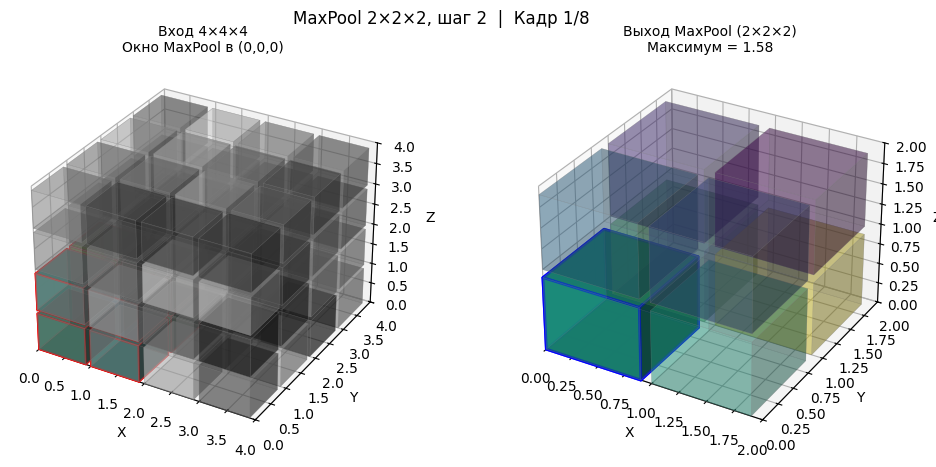

In [2]:
# Генерируем вход 4x4x4
torch.manual_seed(123)
input_4d = torch.randn(1, 1, 4, 4, 4)
input_np_pool = input_4d.squeeze().numpy()

pool = nn.MaxPool3d(2, 2)  # kernel=2, stride=2, padding=0
output_pool = pool(input_4d).squeeze().numpy()  # форма (2,2,2)

# Собираем кадры: 8 позиций (2x2x2)
frames_pool = []
for d_out in range(2):
    for h_out in range(2):
        for w_out in range(2):
            d_start = d_out * 2
            h_start = h_out * 2
            w_start = w_out * 2
            window = input_np_pool[d_start:d_start+2, h_start:h_start+2, w_start:w_start+2]
            max_val = np.max(window)
            frames_pool.append({
                'window': window,
                'start': (d_start, h_start, w_start),
                'out_pos': (d_out, h_out, w_out),
                'max_val': max_val
            })

vmin_pool, vmax_pool = input_np_pool.min(), input_np_pool.max()

fig2 = plt.figure(figsize=(12, 5))
ax_in2 = fig2.add_subplot(121, projection='3d')
ax_out2 = fig2.add_subplot(122, projection='3d')

def update_pool(frame_idx):
    info = frames_pool[frame_idx]
    d0, h0, w0 = info['start']
    d_out, h_out, w_out = info['out_pos']
    max_val = info['max_val']
    
    # --- Вход 4×4×4 (серый) + подсветка окна 2×2×2 ---
    ax_in2.clear()
    x, y, z = np.indices((4,4,4)).reshape(3, -1)
    vals = input_np_pool.flatten()
    colors_gray = plt.cm.Greys((vals - vmin_pool) / (vmax_pool - vmin_pool + 1e-8))
    ax_in2.bar3d(x, y, z, 0.9, 0.9, 0.9, color=colors_gray, alpha=0.4, edgecolor='gray', linewidth=0.3)
    
    # Подсвечиваем окно
    for dz in range(2):
        for dy in range(2):
            for dx in range(2):
                val_in = input_np_pool[d0+dz, h0+dy, w0+dx]
                color = plt.cm.viridis((val_in - vmin_pool) / (vmax_pool - vmin_pool + 1e-8))
                ax_in2.bar3d(w0+dx, h0+dy, d0+dz, 0.9, 0.9, 0.9,
                             color=color, alpha=0.9, edgecolor='red', linewidth=1.2)
    
    ax_in2.set_xlim(0, 4)
    ax_in2.set_ylim(0, 4)
    ax_in2.set_zlim(0, 4)
    ax_in2.set_xlabel('X')
    ax_in2.set_ylabel('Y')
    ax_in2.set_zlabel('Z')
    ax_in2.set_title(f'Вход 4×4×4\nОкно MaxPool в ({w0},{h0},{d0})', fontsize=10)
    
    # --- Выход 2×2×2 ---
    ax_out2.clear()
    out_vals = output_pool.flatten()
    out_vmin, out_vmax = out_vals.min(), out_vals.max()
    out_x, out_y, out_z = np.indices((2,2,2)).reshape(3, -1)
    out_colors = plt.cm.viridis((out_vals - out_vmin) / (out_vmax - out_vmin + 1e-8))
    ax_out2.bar3d(out_x, out_y, out_z, 0.9, 0.9, 0.9,
                  color=out_colors, alpha=0.3, edgecolor='gray', linewidth=0.3)
    
    # Подсвечиваем текущий выходной воксель
    color_cur = plt.cm.viridis((max_val - out_vmin) / (out_vmax - out_vmin + 1e-8))
    ax_out2.bar3d(w_out, h_out, d_out, 0.9, 0.9, 0.9,
                  color=color_cur, alpha=0.9, edgecolor='blue', linewidth=2)
    
    ax_out2.set_xlim(0, 2)
    ax_out2.set_ylim(0, 2)
    ax_out2.set_zlim(0, 2)
    ax_out2.set_xlabel('X')
    ax_out2.set_ylabel('Y')
    ax_out2.set_zlabel('Z')
    ax_out2.set_title(f'Выход MaxPool (2×2×2)\nМаксимум = {max_val:.2f}', fontsize=10)
    
    plt.suptitle(f'MaxPool 2×2×2, шаг 2  |  Кадр {frame_idx+1}/{len(frames_pool)}', fontsize=12)

ani_pool = FuncAnimation(fig2, update_pool, frames=len(frames_pool), interval=1000, repeat=True)
ani_pool.save('maxpool3d_clean.gif', writer='pillow', fps=1.5)
print("✅ Анимация MaxPool сохранена: maxpool3d_clean.gif")